# Метод ближайших соседей

Задача: определить вид ириса по размерам цветка.


Посмотрим, как KNN строит границы классов и реагирует на изменение числа соседей и масштаба признаков.

## Подключение библиотек

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.axes import Axes
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from sklearn.datasets import load_iris, make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# fixing random_state for reproducibility
RANDOM_STATE = 42

# задаем число соседей - гиперпараметр k
N_NEIGHBORS = 3

# seaborn settings
COLORS = ("#238B86", "#ED8936", "#3B70D6")
MARKERS = ("o", "s", "^")

sns.set_theme(style="whitegrid", font="DejaVu Sans")
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.2
    }
)

## Загрузка датасета

В датасете Iris 150 цветков трёх видов: setosa, versicolor и virginica.

Для каждого измерены длина и ширина чашелистика и лепестка в сантиметрах.

Столбец `target` содержит код вида.

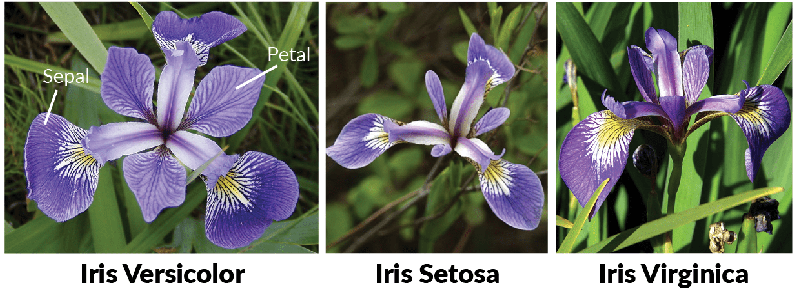

In [3]:
iris = load_iris(as_frame=True)
feature_names = [
    "Длина чашелистика, см",
    "Ширина чашелистика, см",
    "Длина лепестка, см",
    "Ширина лепестка, см"
]
class_names = dict(enumerate(iris.target_names))

df = iris.frame.rename(
    columns=dict(zip(iris.feature_names, feature_names, strict=True))
)
display(df.head())
display(pd.Series(class_names, name="Вид").rename_axis("Класс").to_frame())
print(f"Объектов: {len(df)}, признаков: {len(feature_names)}")

,"Длина чашелистика, см","Ширина чашелистика, см","Длина лепестка, см","Ширина лепестка, см",target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,Вид
Класс,
0,setosa
1,versicolor
2,virginica


Объектов: 150, признаков: 4


## Разделение данных

Обучающую выборку используем для обучения, валидационную — для сравнения
настроек, тестовую — для финальной проверки. Параметр `stratify` сохраняет
доли классов при разбиении.

In [4]:
x_dev, x_test_all, y_dev, y_test = train_test_split(
    df[feature_names],
    df["target"],
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE
)
x_train_all, x_val_all, y_train, y_val = train_test_split(
    x_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

print(f"Train: {len(y_train)}, validation: {len(y_val)}, test: {len(y_test)}")

Train: 90, validation: 30, test: 30


## Получение статистической информации о датасете

In [5]:
x_train_all.info()
display(x_train_all.describe().round(2))

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, 124 to 88
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Длина чашелистика, см   90 non-null     float64
 1   Ширина чашелистика, см  90 non-null     float64
 2   Длина лепестка, см      90 non-null     float64
 3   Ширина лепестка, см     90 non-null     float64
dtypes: float64(4)
memory usage: 3.5 KB


,"Длина чашелистика, см","Ширина чашелистика, см","Длина лепестка, см","Ширина лепестка, см"
count,90.00,90.00,90.00,90.00
mean,5.84,3.01,3.75,1.20
std,0.87,0.42,1.77,0.76
min,4.30,2.00,1.10,0.10
25%,5.10,2.72,1.60,0.30
50%,5.75,3.00,4.25,1.30
75%,6.40,3.20,5.10,1.80
max,7.90,3.90,6.90,2.50


### Распределение классов

,Число цветков
target,
setosa,30
versicolor,30
virginica,30


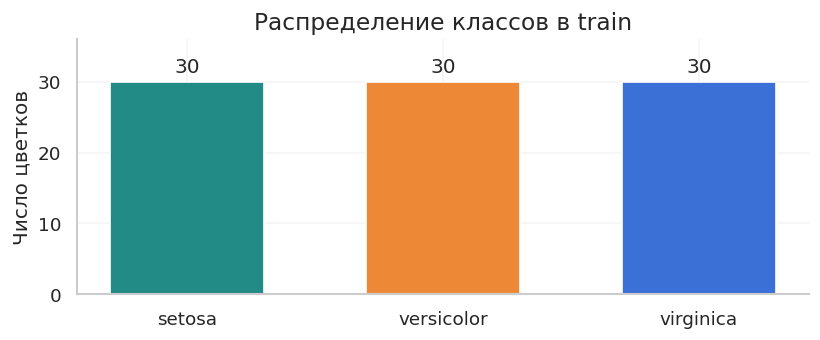

In [7]:
class_counts = y_train.value_counts().sort_index()
display(class_counts.rename(index=class_names).rename("Число цветков").to_frame())

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(iris.target_names, class_counts, color=COLORS, width=0.6)
ax.bar_label(bars, padding=3)
ax.set(ylabel="Число цветков", title="Распределение классов в train", ylim=(0, 36))
fig.tight_layout()
plt.show()

## Визуализация признаков

Сравним две пары признаков.

На какой из них проще различить виды?

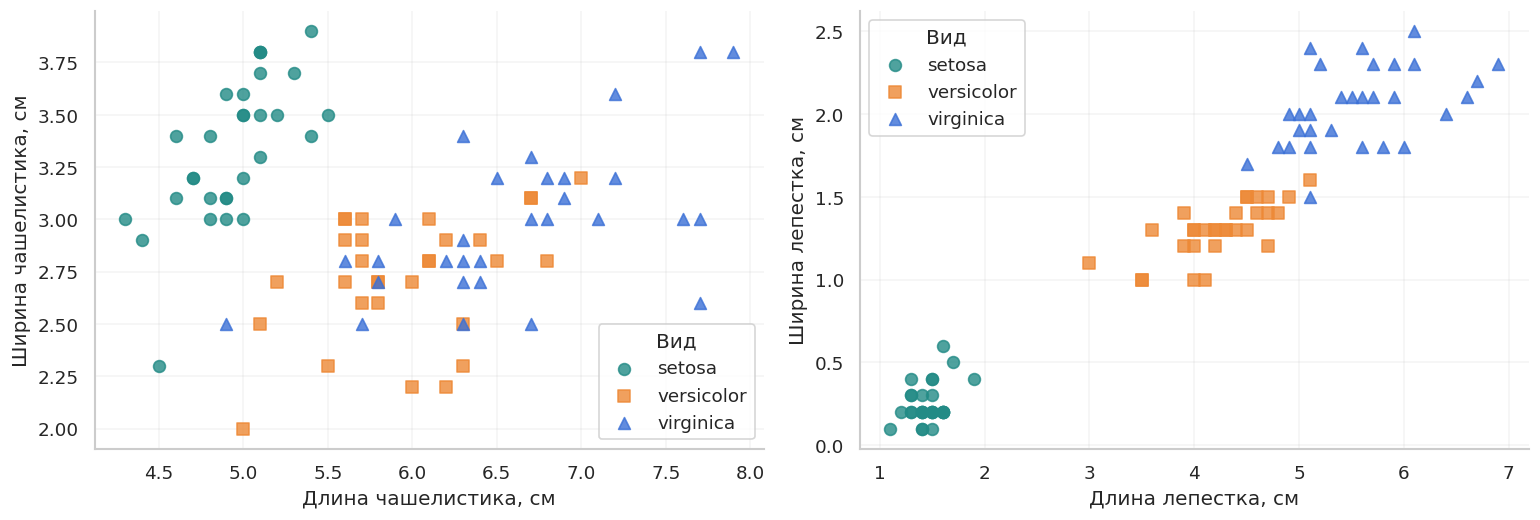

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, features in zip(axes, [feature_names[:2], feature_names[2:]], strict=True):
    for class_id, name in class_names.items():
        group = x_train_all.loc[y_train == class_id, features]
        ax.scatter(
            group.iloc[:, 0],
            group.iloc[:, 1],
            color=COLORS[class_id],
            marker=MARKERS[class_id],
            label=name,
            s=50,
            alpha=0.8
        )
    ax.set(xlabel=features[0], ylabel=features[1])
    ax.legend(title="Вид")

fig.tight_layout()
plt.show()

Матрица попарных графиков (pairplot) позволяет посмотреть все сочетания признаков.
На диагонали показаны распределения отдельных признаков.

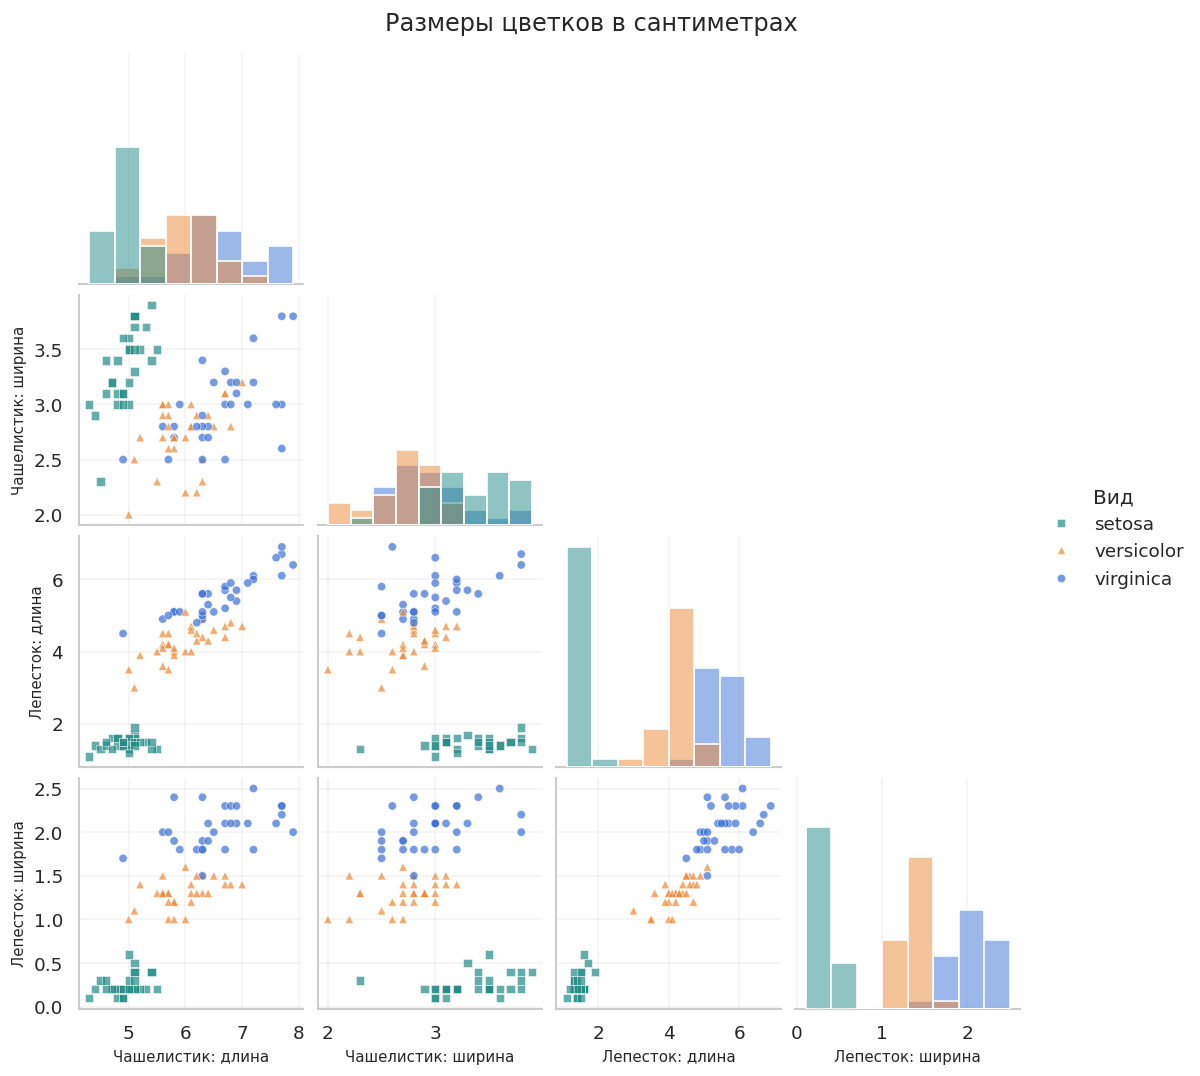

In [9]:
short_names = [
    "Чашелистик: длина",
    "Чашелистик: ширина",
    "Лепесток: длина",
    "Лепесток: ширина",
]
plot_df = x_train_all.set_axis(short_names, axis="columns")
plot_df["Вид"] = y_train.map(class_names)

pair_grid = sns.pairplot(
    plot_df,
    vars=short_names,
    hue="Вид",
    hue_order=list(class_names.values()),
    palette=list(COLORS),
    markers=list(MARKERS),
    diag_kind="hist",
    corner=True,
    height=2.2,
    plot_kws={"s": 25, "alpha": 0.7}
)
for ax in pair_grid.axes.flat:
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=9)
        ax.set_ylabel(ax.get_ylabel(), fontsize=9)
pair_grid.fig.suptitle("Размеры цветков в сантиметрах", y=1.02)
plt.show()

## Обучение KNN

Для наглядности визуализации возьмём два признака: длину и ширину лепестка. По ним будем обучать модель,
оценивать её качество и строить границы классов.

При равных весах KNN выбирает класс, который чаще встречается среди
$k$ ближайших соседей. Используем евклидово расстояние:

$$
d(x, z) = \sqrt{(x_1 - z_1)^2 + (x_2 - z_2)^2}.
$$

In [11]:
selected_features = feature_names[2:]
x_train = x_train_all[selected_features]
x_val = x_val_all[selected_features]
x_test = x_test_all[selected_features]

knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## Предсказание для нового цветка

Зададим цветок с длиной лепестка 4,8 см и шириной 1,65 см.
Его настоящий вид неизвестен. Модель возвращает предсказание.

In [12]:
new_flower = pd.DataFrame([[4.8, 1.65]], columns=selected_features)
predicted_class = int(knn.predict(new_flower)[0])

display(new_flower)
print(f"Предсказанный вид: {class_names[predicted_class]}")

,"Длина лепестка, см","Ширина лепестка, см"
0,4.8,1.65


Предсказанный вид: versicolor


### Ближайшие соседи

Метод `kneighbors` возвращает расстояния и позиции соседей в обучающей выборке.
Посмотрим, какие объекты участвовали в голосовании.

In [14]:
distances, positions = knn.kneighbors(new_flower, n_neighbors = N_NEIGHBORS)
neighbor_positions = positions[0]
neighbor_classes = y_train.iloc[neighbor_positions]

neighbors = x_train.iloc[neighbor_positions].copy()
neighbors.index.name = "Индекс Iris"
neighbors["Расстояние, см"] = distances[0]
neighbors["Вид"] = neighbor_classes.map(class_names)
display(neighbors.round(3))

votes = neighbor_classes.value_counts().reindex(class_names, fill_value=0)
display(votes.rename(index=class_names).rename("Голосов").to_frame())

,"Длина лепестка, см","Ширина лепестка, см","Расстояние, см",Вид
Индекс Iris,,,,
126,4.8,1.8,0.15,virginica
86,4.7,1.5,0.18,versicolor
72,4.9,1.5,0.18,versicolor


,Голосов
target,
setosa,0
versicolor,2
virginica,1


In [17]:
# @title Вспомогательная функция для визуализации ближайших соседей
def plot_neighbors(
    ax: Axes,
    x: pd.DataFrame,
    y: pd.Series,
    query: pd.DataFrame,
    positions: np.ndarray
) -> None:
    """
    Показать выбранных соседей в исходных координатах
    """
    for class_id in sorted(y.unique()):
        group = x.loc[y == class_id]
        ax.scatter(
            group.iloc[:, 0],
            group.iloc[:, 1],
            color=COLORS[class_id],
            marker=MARKERS[class_id],
            label=class_names[class_id],
            s=45,
            alpha=0.4
        )

    query_point = query.iloc[0].to_numpy()
    for rank, point in enumerate(x.iloc[positions].to_numpy(), start=1):
        ax.plot(
            [query_point[0], point[0]],
            [query_point[1], point[1]],
            color="#697789",
            linewidth=1
        )
        ax.scatter(*point, s=150, facecolors="none", edgecolors="#172438")
        ax.annotate(str(rank), point, xytext=(7, 7), textcoords="offset points")

    ax.scatter(*query_point, marker="*", s=250, color="#172438", zorder=5)
    ax.set(xlabel=x.columns[0], ylabel=x.columns[1])
    ax.legend(title="Вид", fontsize=9)

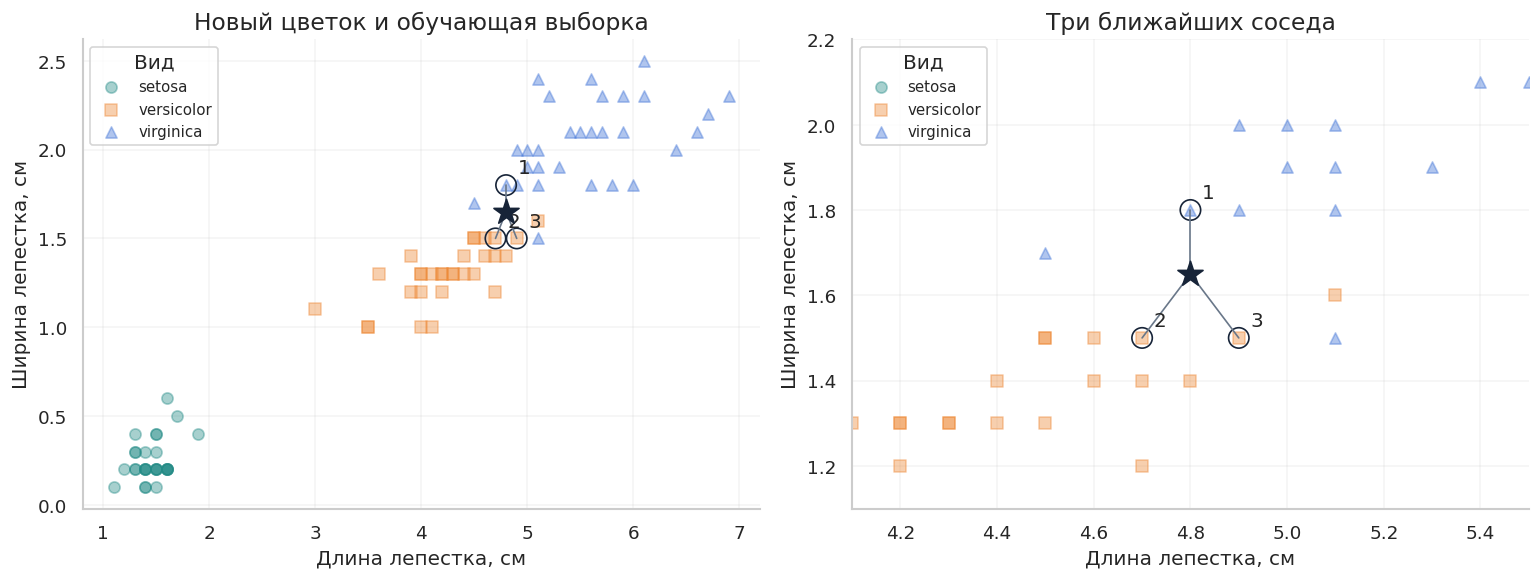

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax in axes:
    plot_neighbors(ax, x_train, y_train, new_flower, neighbor_positions)

axes[0].set_title("Новый цветок и обучающая выборка")
axes[1].set(
    title="Три ближайших соседа",
    xlim=(4.1, 5.5),
    ylim=(1.1, 2.2)
)
fig.tight_layout()
plt.show()

## Границы классов

Расположим новые объекты на регулярной сетке и предскажем класс каждого.

Цвет фона показывает ответ модели, цвет обучающей точки — настоящий класс.

Выделяем ошибки на валидационной выборке.

In [21]:
# @title Вспомогательная функция для отображения разделяющих поверхностей
def plot_decision_regions(
    ax: Axes,
    model: KNeighborsClassifier | Pipeline,
    x_train: pd.DataFrame,
    y_train: pd.Series,
    x_check: pd.DataFrame,
    y_check: pd.Series
) -> None:
    """
    Построить карту классов и отметить ошибки на проверочной выборке
    """
    x_values = np.linspace(
        x_train.iloc[:, 0].min() - 0.3,
        x_train.iloc[:, 0].max() + 0.3,
        180
    )
    y_values = np.linspace(
        x_train.iloc[:, 1].min() - 0.2,
        x_train.iloc[:, 1].max() + 0.2,
        180
    )
    grid_x, grid_y = np.meshgrid(x_values, y_values)
    grid = pd.DataFrame(
        np.column_stack([grid_x.ravel(), grid_y.ravel()]),
        columns=x_train.columns
    )
    grid_classes = model.predict(grid).reshape(grid_x.shape)
    classes = np.sort(y_train.unique())

    ax.contourf(
        grid_x,
        grid_y,
        grid_classes,
        levels=np.arange(len(classes) + 1) - 0.5,
        cmap=ListedColormap(COLORS[: len(classes)]),
        alpha=0.18
    )
    for class_id in classes:
        group = x_train.loc[y_train == class_id]
        ax.scatter(
            group.iloc[:, 0],
            group.iloc[:, 1],
            color=COLORS[class_id],
            marker=MARKERS[class_id],
            s=28,
            alpha=0.65
        )

    ax.scatter(
        x_check.iloc[:, 0],
        x_check.iloc[:, 1],
        c=[COLORS[class_id] for class_id in y_check],
        marker="D",
        s=50,
        edgecolors="#172438",
        linewidths=0.6
    )
    errors = model.predict(x_check) != y_check.to_numpy()
    ax.scatter(
        x_check.loc[errors].iloc[:, 0],
        x_check.loc[errors].iloc[:, 1],
        s=160,
        facecolors="none",
        edgecolors="#172438",
        linewidths=1.5
    )
    ax.set(
        xlabel=x_train.columns[0],
        ylabel=x_train.columns[1],
        xlim=(x_values[0], x_values[-1]),
        ylim=(y_values[0], y_values[-1])
    )

## Оценка качества

Accuracy — доля правильных ответов:

$$
\mathrm{accuracy}
= \frac{\text{число правильных предсказаний}}{\text{число объектов}}.
$$

Верно: 28 из 30. Accuracy: 93.3%


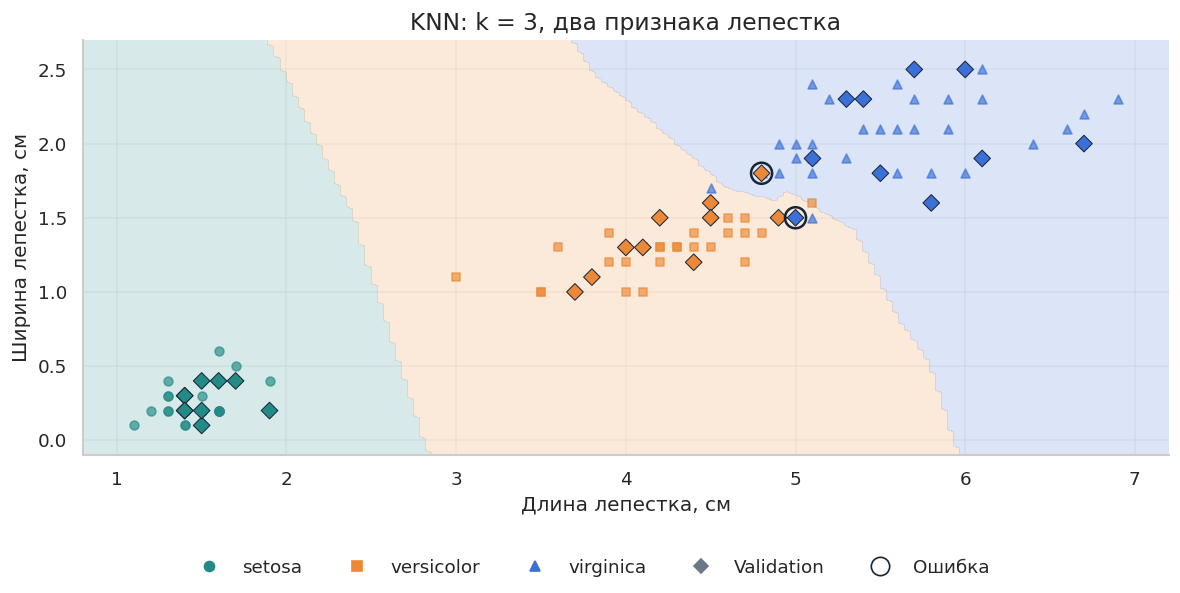

In [23]:
val_predictions = knn.predict(x_val)
correct_count = np.count_nonzero(val_predictions == y_val.to_numpy())
accuracy = accuracy_score(y_val, val_predictions)

print(f"Верно: {correct_count} из {len(y_val)}. Accuracy: {accuracy:.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
plot_decision_regions(ax, knn, x_train, y_train, x_val, y_val)
ax.set_title(f"KNN: k = {N_NEIGHBORS}, два признака лепестка")

legend_handles = [
    Line2D(
        [],
        [],
        marker=MARKERS[class_id],
        linestyle="none",
        color=COLORS[class_id],
        label=name,
    )
    for class_id, name in class_names.items()
]
legend_handles.extend(
    [
        Line2D(
            [],
            [],
            marker="D",
            linestyle="none",
            color="#697789",
            label="Validation",
        ),
        Line2D(
            [],
            [],
            marker="o",
            linestyle="none",
            color="#172438",
            markerfacecolor="none",
            markersize=11,
            label="Ошибка",
        ),
    ]
)
fig.legend(handles=legend_handles, loc="lower center", ncol=5, frameon=False)
fig.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

## Влияние числа соседей

Сравним разделяющие поверхности при k = 1, 5 и 25.

Данные и разбиение остаются прежними.

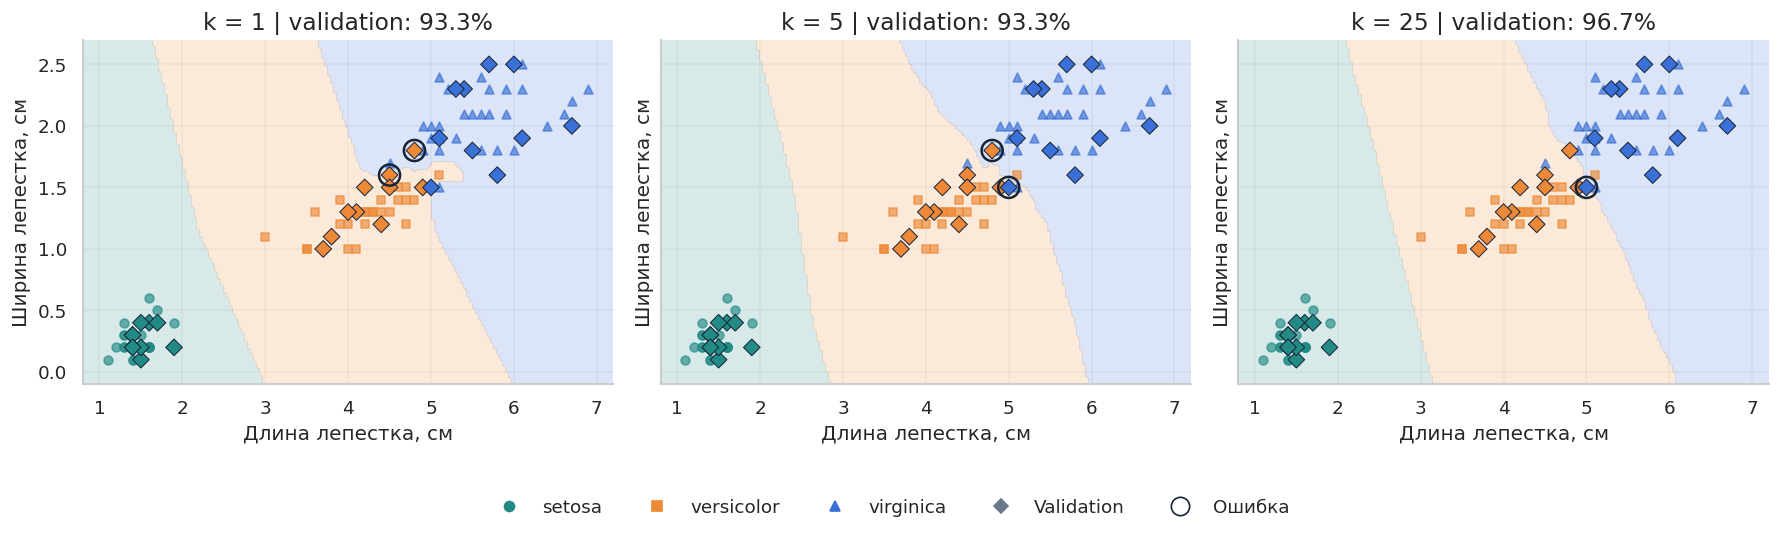

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)

for k, ax in zip([1, 5, 25], axes, strict=True):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    score = accuracy_score(y_val, model.predict(x_val))
    plot_decision_regions(ax, model, x_train, y_train, x_val, y_val)
    ax.set_title(f"k = {k} | validation: {score:.1%}")

fig.legend(handles=legend_handles, loc="lower center", ncol=5, frameon=False)
fig.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

## Масштаб признаков

Переведём **один признак - длину лепестка** из сантиметров в миллиметры, оставив ширину в сантиметрах.
Изменятся ли ближайшие соседи?

,Соседи: длина в см,Соседи: длина в мм
0,126,126
1,86,76
2,72,86


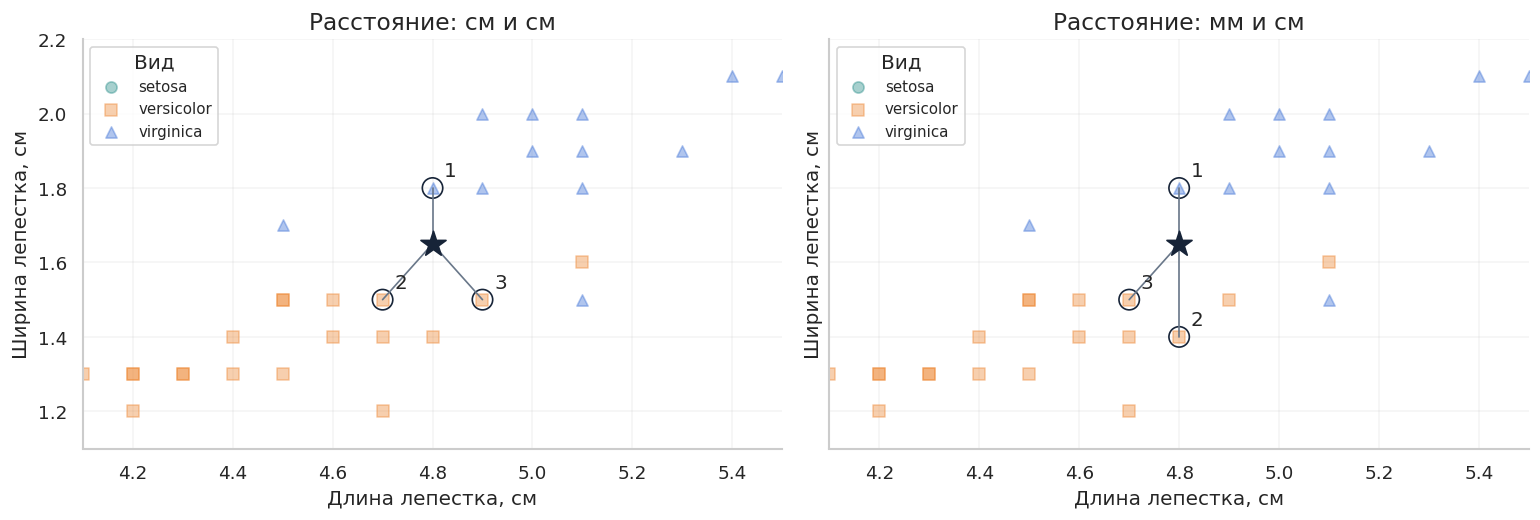

In [25]:
x_train_mm = x_train.copy()
new_flower_mm = new_flower.copy()
x_train_mm.iloc[:, 0] *= 10
new_flower_mm.iloc[:, 0] *= 10

knn_mm = KNeighborsClassifier(n_neighbors=3)
knn_mm.fit(x_train_mm, y_train)
positions_mm = knn_mm.kneighbors(new_flower_mm, return_distance=False)[0]

display(
    pd.DataFrame(
        {
            "Соседи: длина в см": x_train.index[neighbor_positions],
            "Соседи: длина в мм": x_train.index[positions_mm],
        }
    )
)

# На обоих рисунках оставляем сантиметры, чтобы сравнить выбор соседей.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, positions, title in zip(
    axes,
    [neighbor_positions, positions_mm],
    ["Расстояние: см и см", "Расстояние: мм и см"],
    strict=True,
):
    plot_neighbors(ax, x_train, y_train, new_flower, positions)
    ax.set(title=title, xlim=(4.1, 5.5), ylim=(1.1, 2.2))

fig.tight_layout()
plt.show()

### Стандартизация

Признак с большим числовым масштабом сильнее влияет на евклидово расстояние.
Стандартизация выражает каждый признак в единицах его разброса:

$$
z_j = \frac{x_j - \mu_j}{\sigma_j}.
$$

Среднее $\mu_j$ и стандартное отклонение $\sigma_j$ вычисляем по train.
Для validation и новых объектов используем те же значения.
Стандартизация не делает распределение нормальным и не гарантирует роста accuracy.

In [26]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)

knn_scaled = KNeighborsClassifier(n_neighbors=3)
knn_scaled.fit(x_train_scaled, y_train)
scaled_predictions = knn_scaled.predict(x_val_scaled)
print(f"Accuracy после стандартизации: {accuracy_score(y_val, scaled_predictions):.1%}")

Accuracy после стандартизации: 93.3%


Pipeline объединяет стандартизацию и KNN. В него передаём исходные признаки;
преобразование выполняется внутри модели.

In [27]:
scaled_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=N_NEIGHBORS),
)
scaled_model.fit(x_train, y_train)

scaled_model_mm = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=N_NEIGHBORS),
)
scaled_model_mm.fit(x_train_mm, y_train)

query_scaled = scaled_model.named_steps["standardscaler"].transform(new_flower)
query_scaled_mm = scaled_model_mm.named_steps["standardscaler"].transform(new_flower_mm)
print(
    "Координаты после стандартизации совпадают:",
    np.allclose(query_scaled, query_scaled_mm)
)

Координаты после стандартизации совпадают: True


## Сравнение настроек KNN

Сравним равные веса и веса по расстоянию. При `weights="distance"` более
близкие соседи сильнее влияют на ответ.

Все модели ниже используют стандартизацию. Настройки выбираем по validation.

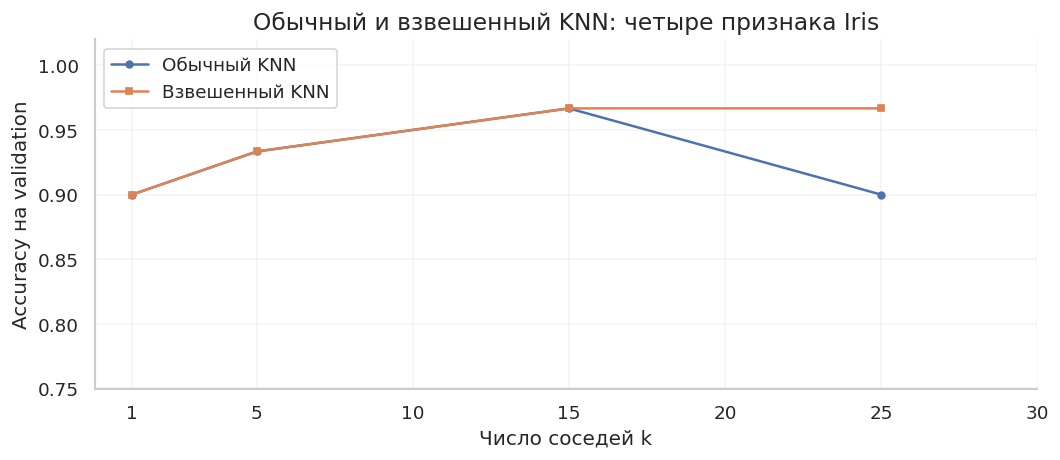

    k   weights  val_accuracy
0   1   uniform      0.900000
1   5   uniform      0.933333
2  15   uniform      0.966667
3  25   uniform      0.900000
4   1  distance      0.900000
5   5  distance      0.933333
6  15  distance      0.966667
7  25  distance      0.966667


In [28]:
k_values = [1, 5, 15, 25]
results = []

fig, ax = plt.subplots(figsize=(9, 4))

for weights, label, marker in [
    ("uniform", "Обычный KNN", "o"),
    ("distance", "Взвешенный KNN", "s"),
]:
    scores = []

    for k in k_values:
        model = make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=k, weights=weights),
        )
        model.fit(x_train_all, y_train)
        predictions = model.predict(x_val_all)
        score = accuracy_score(y_val, predictions)

        scores.append(score)
        results.append(
            {
                "k": k,
                "weights": weights,
                "val_accuracy": score,
            }
        )

    ax.plot(k_values, scores, marker=marker, markersize=4, label=label)

results_df = pd.DataFrame(results)

ax.set(
    xlabel="Число соседей k",
    ylabel="Accuracy на validation",
    title="Обычный и взвешенный KNN: четыре признака Iris",
    xticks=[1, 5, 10, 15, 20, 25, 30],
    ylim=(0.75, 1.02),
)
ax.legend()
fig.tight_layout()
plt.show()
print(results_df)

In [29]:
best_result = results_df.sort_values(
    ["val_accuracy", "weights", "k"],
    ascending=[False, False, False],
).iloc[0]
best_k = int(best_result["k"])
best_weights = str(best_result["weights"])
print(f"Выбрано k = {best_k}, weights = '{best_weights}'")

Выбрано k = 15, weights = 'uniform'


## Задание для самостоятельной работы

Обучить KNN на train и validation.

Получить значение метрики на тестовой выборке и количество ошибок.

Построить визуализацию только для тестовой выборки.


In [ ]:
# Your code here